<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/tugas_FiturLokal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Praktikum 12 – Object Matching & Feature Descriptor
## Implementasi SIFT, ORB, BoVW, PCA, dan Evaluasi Komprehensif

**Dataset:** 5 objek (buku, mug, botol, mainan, remote)  
**Metode:** SIFT · ORB · BF Matching · FLANN · Lowe's Ratio Test · RANSAC · BoVW · PCA  
**Evaluasi:** Precision-Recall · Confusion Matrix · Perbandingan kecepatan & akurasi

## 📦 Cell 1 – Instalasi & Import Library

In [1]:
# Install library yang dibutuhkan
!pip install opencv-contrib-python scikit-learn scikit-image matplotlib seaborn numpy -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

print('✅ Semua library berhasil diimport')
print(f'OpenCV version: {cv2.__version__}')

# Cek ketersediaan SIFT dan SURF
try:
    sift_test = cv2.SIFT_create()
    SIFT_AVAILABLE = True
    print('✅ SIFT tersedia')
except:
    SIFT_AVAILABLE = False
    print('❌ SIFT tidak tersedia')

try:
    surf_test = cv2.xfeatures2d.SURF_create()
    SURF_AVAILABLE = True
    print('✅ SURF tersedia')
except:
    SURF_AVAILABLE = False
    print('⚠️  SURF tidak tersedia (paten) – akan dilewati')

ORB_AVAILABLE = True
print('✅ ORB tersedia')

✅ Semua library berhasil diimport
OpenCV version: 4.13.0
✅ SIFT tersedia
⚠️  SURF tidak tersedia (paten) – akan dilewati
✅ ORB tersedia


## 🖼️ Cell 2 – Pembuatan Dataset Sintetis (5 Objek × Variasi)

✅ Dataset dibuat: 25 citra, 5 kelas
   Per kelas: 1 referensi + 4 uji = 5 citra/kelas


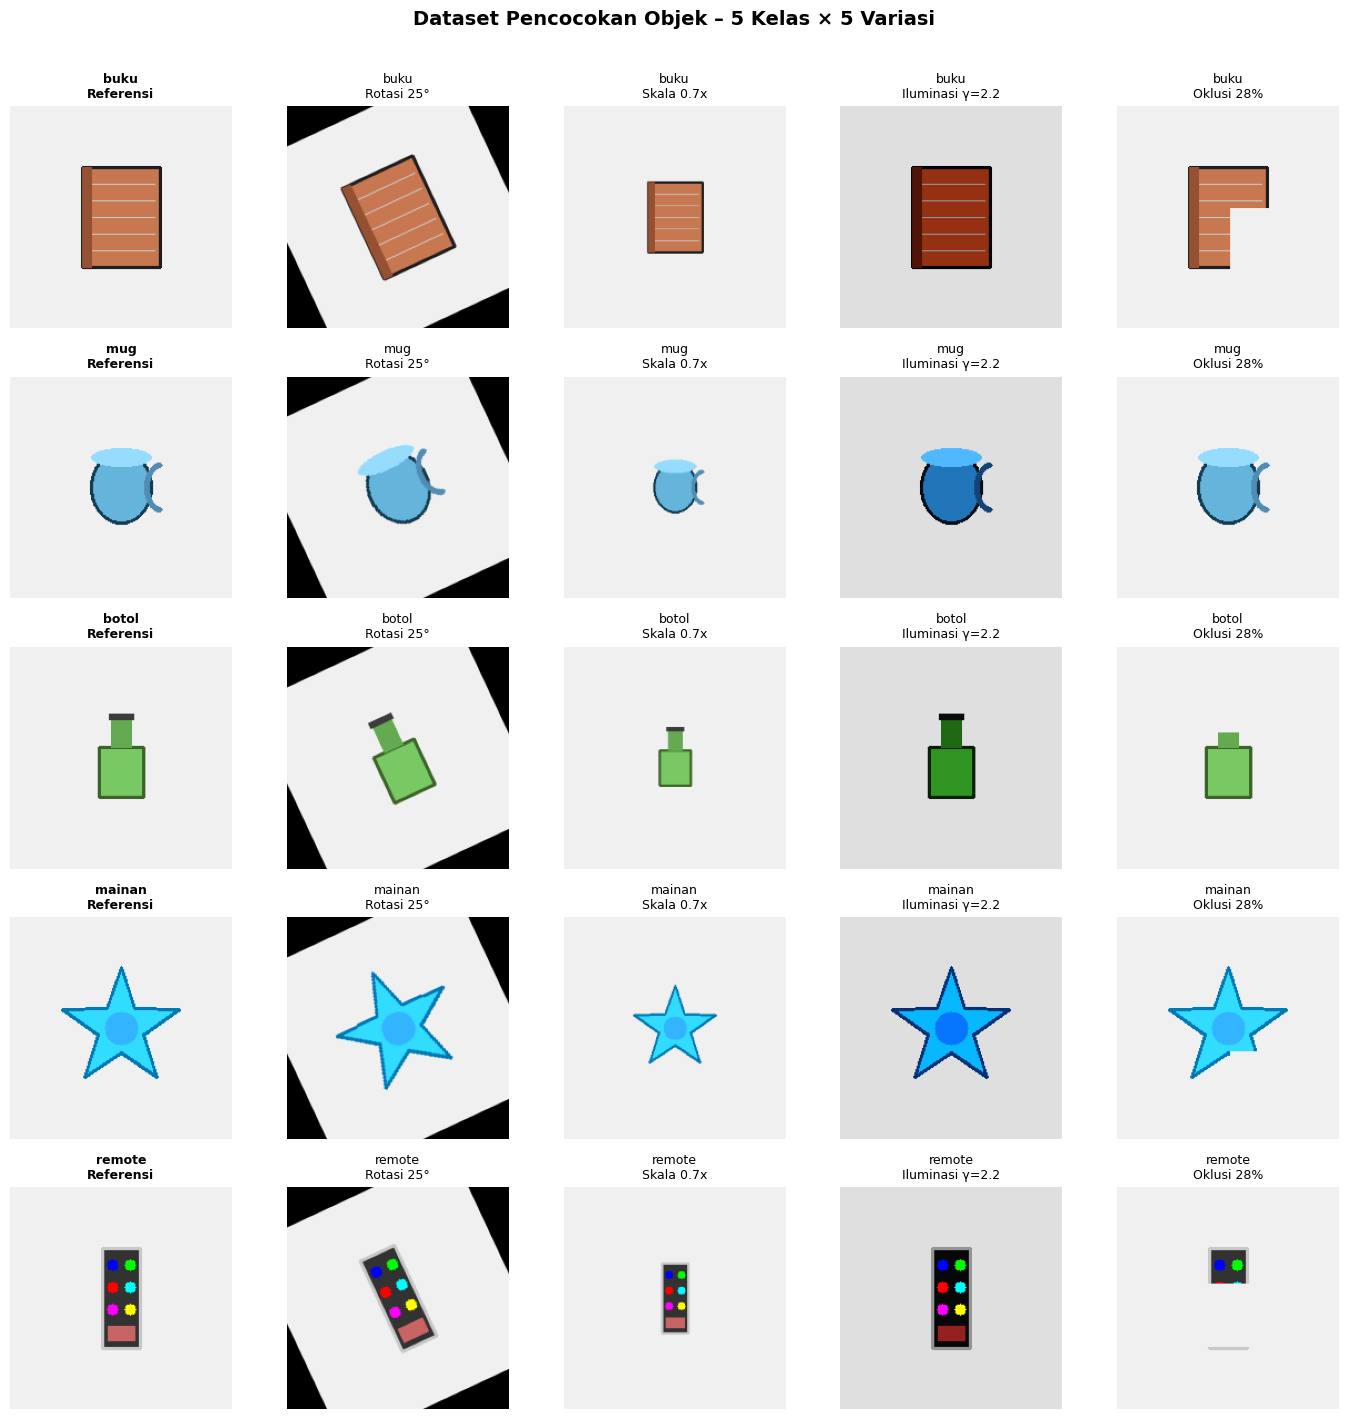

  (border merah = citra referensi)


In [2]:
# ============================================================
# DATASET SINTETIS – 5 objek, masing-masing 1 referensi + 4 uji
# Variasi: rotasi, skala, iluminasi, oklusi parsial
# ============================================================

OBJECT_NAMES = ['buku', 'mug', 'botol', 'mainan', 'remote']
IMG_SIZE = 200
np.random.seed(42)

def draw_buku(img, scale=1.0, color_shift=0):
    """Gambar objek buku (persegi panjang + garis halaman)"""
    cx, cy = IMG_SIZE//2, IMG_SIZE//2
    w, h = int(70*scale), int(90*scale)
    cv2.rectangle(img, (cx-w//2, cy-h//2), (cx+w//2, cy+h//2),
                  (int(80+color_shift), int(120+color_shift), int(200+color_shift)), -1)
    cv2.rectangle(img, (cx-w//2, cy-h//2), (cx+w//2, cy+h//2), (30,30,30), 2)
    for i in range(1, 6):
        y_line = cy - h//2 + i * h//6
        cv2.line(img, (cx-w//2+5, y_line), (cx+w//2-5, y_line), (200,200,200), 1)
    cv2.rectangle(img, (cx-w//2, cy-h//2), (cx-w//2+8, cy+h//2), (50,80,150), -1)
    return img

def draw_mug(img, scale=1.0, color_shift=0):
    """Gambar objek mug (silinder + handle)"""
    cx, cy = IMG_SIZE//2, IMG_SIZE//2
    w, h = int(55*scale), int(65*scale)
    cv2.ellipse(img, (cx, cy), (w//2, h//2), 0, 0, 360,
                (int(220+color_shift), int(180+color_shift), int(100+color_shift)), -1)
    cv2.ellipse(img, (cx, cy), (w//2, h//2), 0, 0, 360, (80,60,20), 2)
    # handle
    cv2.ellipse(img, (cx+w//2+8, cy), (12, 20), 0, 270, 90, (180,140,80), 3)
    # rim
    cv2.ellipse(img, (cx, cy-h//2+5), (w//2, 8), 0, 0, 360, (255,220,150), -1)
    return img

def draw_botol(img, scale=1.0, color_shift=0):
    """Gambar objek botol (badan + leher + tutup)"""
    cx, cy = IMG_SIZE//2, IMG_SIZE//2
    bw, bh = int(40*scale), int(70*scale)
    nw, nh = int(18*scale), int(25*scale)
    cv2.rectangle(img, (cx-bw//2, cy-bh//2+nh), (cx+bw//2, cy+bh//2),
                  (int(100+color_shift), int(200+color_shift), int(120+color_shift)), -1)
    cv2.rectangle(img, (cx-bw//2, cy-bh//2+nh), (cx+bw//2, cy+bh//2), (40,100,60), 2)
    cv2.rectangle(img, (cx-nw//2, cy-bh//2), (cx+nw//2, cy-bh//2+nh),
                  (int(80+color_shift), int(170+color_shift), int(100+color_shift)), -1)
    cv2.rectangle(img, (cx-nw//2-2, cy-bh//2-5), (cx+nw//2+2, cy-bh//2),
                  (60,60,60), -1)
    return img

def draw_mainan(img, scale=1.0, color_shift=0):
    """Gambar objek mainan (bintang)"""
    cx, cy = IMG_SIZE//2, IMG_SIZE//2
    r_out, r_in = int(55*scale), int(22*scale)
    pts = []
    for i in range(10):
        angle = np.pi/2 + i * 2*np.pi/10
        r = r_out if i % 2 == 0 else r_in
        pts.append([int(cx + r*np.cos(angle)), int(cy - r*np.sin(angle))])
    pts = np.array(pts, np.int32)
    cv2.fillPoly(img, [pts],
                 (int(255+color_shift), int(220+color_shift), int(50+color_shift)))
    cv2.polylines(img, [pts], True, (180,120,0), 2)
    cv2.circle(img, (cx, cy), int(15*scale), (255,180,50), -1)
    return img

def draw_remote(img, scale=1.0, color_shift=0):
    """Gambar objek remote (persegi panjang panjang + tombol)"""
    cx, cy = IMG_SIZE//2, IMG_SIZE//2
    w, h = int(35*scale), int(90*scale)
    cv2.rectangle(img, (cx-w//2, cy-h//2), (cx+w//2, cy+h//2),
                  (int(50+color_shift), int(50+color_shift), int(50+color_shift)), -1)
    cv2.rectangle(img, (cx-w//2, cy-h//2), (cx+w//2, cy+h//2), (200,200,200), 2)
    # tombol-tombol
    button_colors = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255),(0,255,255)]
    positions = [(cx-8,cy-30),(cx+8,cy-30),(cx-8,cy-10),(cx+8,cy-10),
                 (cx-8,cy+10),(cx+8,cy+10)]
    for pos, col in zip(positions, button_colors):
        cv2.circle(img, pos, int(5*scale), col, -1)
    cv2.rectangle(img, (cx-12, cy+25), (cx+12, cy+38), (100,100,200), -1)
    return img

DRAW_FUNCS = [draw_buku, draw_mug, draw_botol, draw_mainan, draw_remote]

def apply_rotation(img, angle):
    M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
    return cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))

def apply_scale(img, factor):
    h, w = img.shape[:2]
    scaled = cv2.resize(img, (int(w*factor), int(h*factor)))
    out = np.full((h, w, 3), 240, dtype=np.uint8)
    sh, sw = scaled.shape[:2]
    y0 = (h - sh) // 2; x0 = (w - sw) // 2
    y0, x0 = max(0,y0), max(0,x0)
    sh, sw = min(sh, h-y0), min(sw, w-x0)
    out[y0:y0+sh, x0:x0+sw] = scaled[:sh, :sw]
    return out

def apply_illumination(img, gamma):
    table = np.array([(i/255.0)**gamma*255 for i in range(256)], np.uint8)
    return cv2.LUT(img, table)

def apply_occlusion(img, ratio=0.25):
    out = img.copy()
    h, w = out.shape[:2]
    x1 = np.random.randint(0, int(w*(1-ratio)))
    y1 = np.random.randint(0, int(h*(1-ratio)))
    cv2.rectangle(out, (x1,y1), (x1+int(w*ratio), y1+int(h*ratio)), (240,240,240), -1)
    return out

def make_base_image(draw_fn, color_shift=0, scale=1.0):
    img = np.full((IMG_SIZE, IMG_SIZE, 3), 240, dtype=np.uint8)
    return draw_fn(img, scale=scale, color_shift=color_shift)

# Buat dataset
dataset = {}   # dataset[obj_name] = {'ref': img, 'test': [img1..img4], 'labels': [...]}
all_images, all_labels = [], []

for idx, (name, fn) in enumerate(zip(OBJECT_NAMES, DRAW_FUNCS)):
    ref = make_base_image(fn)
    tests = [
        apply_rotation(make_base_image(fn), 25),
        apply_scale(make_base_image(fn), 0.7),
        apply_illumination(make_base_image(fn), 2.2),
        apply_occlusion(make_base_image(fn), 0.28),
    ]
    dataset[name] = {'ref': ref, 'test': tests}
    all_images.append(ref)
    all_labels.append(name)
    for t in tests:
        all_images.append(t)
        all_labels.append(name)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f'✅ Dataset dibuat: {len(all_images)} citra, {len(OBJECT_NAMES)} kelas')
print(f'   Per kelas: 1 referensi + 4 uji = 5 citra/kelas')

# Visualisasi dataset
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
var_labels = ['Referensi', 'Rotasi 25°', 'Skala 0.7x', 'Iluminasi γ=2.2', 'Oklusi 28%']

for row, name in enumerate(OBJECT_NAMES):
    imgs = [dataset[name]['ref']] + dataset[name]['test']
    for col, (im, vl) in enumerate(zip(imgs, var_labels)):
        axes[row, col].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title(f'{name}\n{vl}', fontsize=9, fontweight='bold' if col==0 else 'normal')
        axes[row, col].axis('off')
        if col == 0:
            for sp in axes[row,col].spines.values():
                sp.set_edgecolor('red'); sp.set_linewidth(3); sp.set_visible(True)

plt.suptitle('Dataset Pencocokan Objek – 5 Kelas × 5 Variasi', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('  (border merah = citra referensi)')

## 🔑 Cell 3 – Deteksi & Deskripsi Fitur (SIFT, SURF, ORB)

Detektor aktif: ['SIFT', 'ORB']

TABEL STATISTIK EKSTRAKSI FITUR
Metode       Avg KP   Min KP   Max KP   Dim Desc  Waktu Total(ms)  Waktu/Citra(ms)
----------------------------------------------------------------------
SIFT           28.8        8       88        128           230.23             9.21
ORB           104.6       32      252         32            33.34             1.33


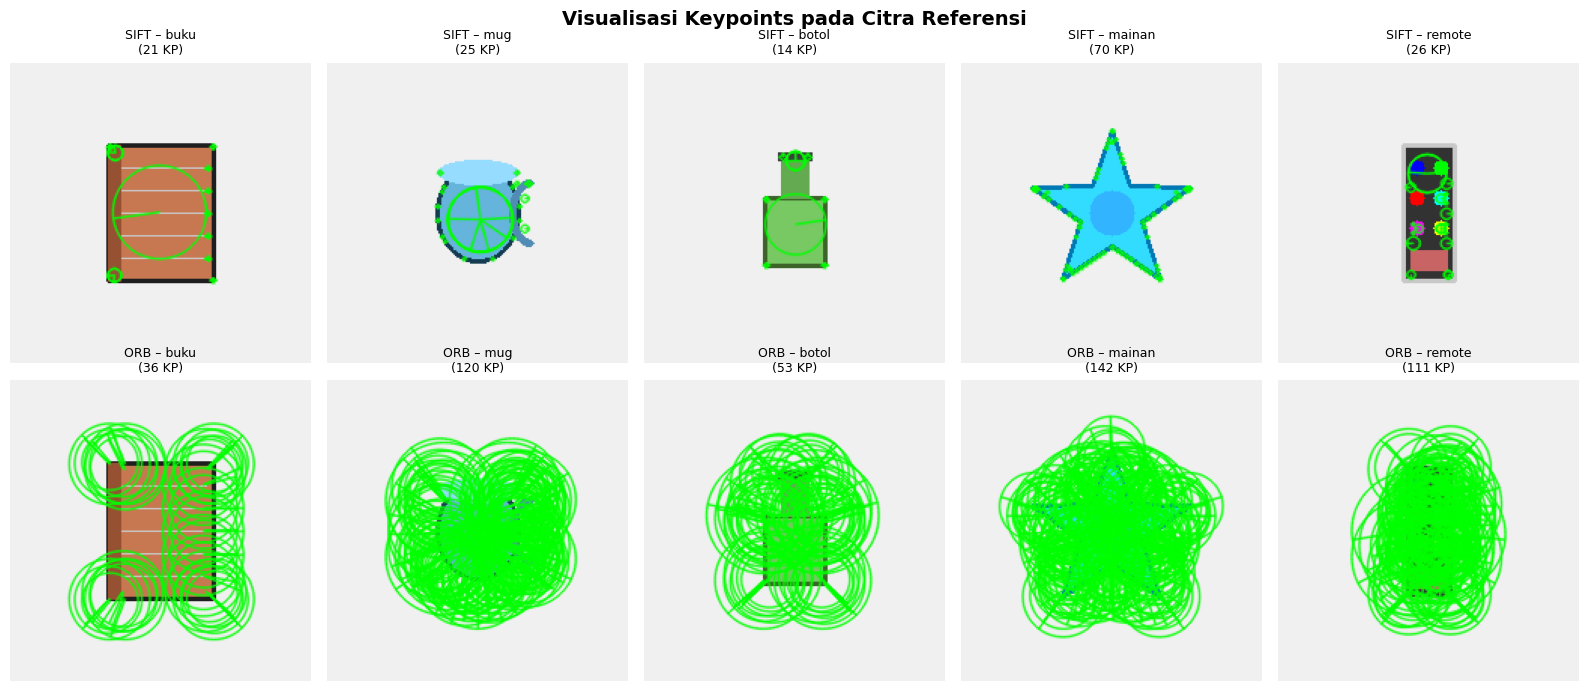

In [3]:
# ============================================================
# DETEKSI & DESKRIPSI FITUR
# Dokumentasi: jumlah keypoints, waktu, dimensi descriptor
# ============================================================

def create_detectors():
    detectors = {}
    if SIFT_AVAILABLE:
        detectors['SIFT'] = cv2.SIFT_create(nfeatures=500)
    if SURF_AVAILABLE:
        detectors['SURF'] = cv2.xfeatures2d.SURF_create(400)
    detectors['ORB'] = cv2.ORB_create(nfeatures=500)
    return detectors

detectors = create_detectors()
print('Detektor aktif:', list(detectors.keys()))

def extract_features(detector, images, name=''):
    results = []
    t0 = time.time()
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, des = detector.detectAndCompute(gray, None)
        results.append({'kp': kp, 'des': des, 'n_kp': len(kp)})
    elapsed = (time.time() - t0) * 1000
    return results, elapsed

# Ekstraksi dari semua citra
feature_store = {}
stats_rows = []

for det_name, det in detectors.items():
    res, elapsed = extract_features(det, all_images, det_name)
    feature_store[det_name] = res
    all_kp = [r['n_kp'] for r in res]
    valid_des = [r['des'] for r in res if r['des'] is not None]
    dim = valid_des[0].shape[1] if valid_des else 0
    stats_rows.append({
        'Metode': det_name,
        'Avg Keypoints': f"{np.mean(all_kp):.1f}",
        'Min KP': min(all_kp),
        'Max KP': max(all_kp),
        'Dimensi Descriptor': dim,
        'Waktu Total (ms)': f"{elapsed:.2f}",
        'Waktu/Citra (ms)': f"{elapsed/len(all_images):.2f}"
    })

print('\n' + '='*70)
print('TABEL STATISTIK EKSTRAKSI FITUR')
print('='*70)
header = ['Metode','Avg KP','Min KP','Max KP','Dim Desc','Waktu Total(ms)','Waktu/Citra(ms)']
print(f'{"Metode":<8} {"Avg KP":>10} {"Min KP":>8} {"Max KP":>8} {"Dim Desc":>10} {"Waktu Total(ms)":>16} {"Waktu/Citra(ms)":>16}')
print('-'*70)
for r in stats_rows:
    print(f"{r['Metode']:<8} {r['Avg Keypoints']:>10} {r['Min KP']:>8} {r['Max KP']:>8} {r['Dimensi Descriptor']:>10} {r['Waktu Total (ms)']:>16} {r['Waktu/Citra (ms)']:>16}")

# Visualisasi keypoints pada citra referensi
fig, axes = plt.subplots(len(detectors), 5, figsize=(16, 3.5*len(detectors)))
if len(detectors) == 1: axes = axes[np.newaxis, :]

for row, (det_name, det) in enumerate(detectors.items()):
    for col, obj_name in enumerate(OBJECT_NAMES):
        img = dataset[obj_name]['ref'].copy()
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, _ = det.detectAndCompute(gray, None)
        img_kp = cv2.drawKeypoints(img, kp, None,
                                    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
                                    color=(0,255,0))
        axes[row, col].imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title(f'{det_name} – {obj_name}\n({len(kp)} KP)', fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Visualisasi Keypoints pada Citra Referensi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('keypoints_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔗 Cell 4 – Feature Matching (BF, FLANN, Ratio Test, RANSAC)

TABEL HASIL FEATURE MATCHING (avg across 4 variasi per objek)
Metode         Objek        Good Matches   RANSAC Inliers    Waktu(ms)
---------------------------------------------------------------------------
SIFT+BF        buku                  6.8              3.8         1.04
SIFT+BF        mug                  16.2             14.2         0.10
SIFT+BF        botol                10.2              9.2         0.06
SIFT+BF        mainan               48.2             40.0         0.26
SIFT+BF        remote               14.8              9.8         0.10
SIFT+FLANN     buku                  6.8              3.8         0.81
SIFT+FLANN     mug                  16.2             14.2         0.43
SIFT+FLANN     botol                10.2              9.2         0.21
SIFT+FLANN     mainan               48.2             40.0         2.66
SIFT+FLANN     remote               14.8              9.8         0.52
ORB+BF         buku                 17.2             16.2         0.13
ORB+BF    

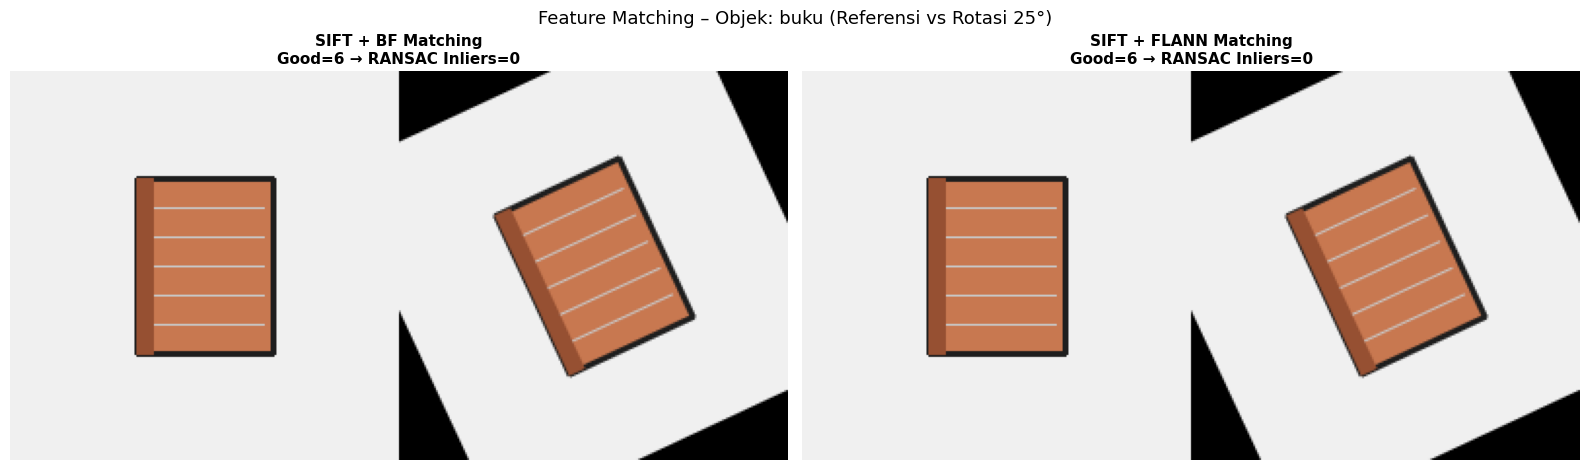

In [4]:
# ============================================================
# FEATURE MATCHING
# BF Matching · FLANN · Lowe's Ratio Test · RANSAC Homography
# ============================================================

def get_matcher(det_name, method='BF'):
    if method == 'BF':
        norm = cv2.NORM_HAMMING if det_name == 'ORB' else cv2.NORM_L2
        return cv2.BFMatcher(norm, crossCheck=False)
    else:  # FLANN
        if det_name == 'ORB':
            idx_params = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
        else:
            idx_params = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        return cv2.FlannBasedMatcher(idx_params, search_params)

def match_features(des1, des2, det_name, method='BF', ratio_thresh=0.75):
    if des1 is None or des2 is None:
        return [], []
    if det_name == 'ORB':
        des1 = des1.astype(np.uint8)
        des2 = des2.astype(np.uint8)
    else:
        des1 = des1.astype(np.float32)
        des2 = des2.astype(np.float32)

    matcher = get_matcher(det_name, method)
    try:
        raw = matcher.knnMatch(des1, des2, k=2)
    except:
        return [], []

    good = []
    for pair in raw:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio_thresh * n.distance:
                good.append(m)
    return raw, good

def apply_ransac(kp1, kp2, good_matches, min_match=4):
    if len(good_matches) < min_match:
        return None, good_matches
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if mask is None:
        return None, good_matches
    inliers = [m for m, keep in zip(good_matches, mask.ravel()) if keep]
    return H, inliers

# Jalankan matching untuk semua kombinasi: det × matching_method × objek
matching_results = {}  # key: (det, method, obj)
matching_stats = []

RATIO_THRESH = 0.75

for det_name in detectors.keys():
    for method in ['BF', 'FLANN']:
        for obj_name in OBJECT_NAMES:
            ref_feat = feature_store[det_name][OBJECT_NAMES.index(obj_name) * 5]
            kp_ref = ref_feat['kp']
            des_ref = ref_feat['des']

            obj_results = []
            for var_idx in range(4):  # 4 variasi uji
                test_feat = feature_store[det_name][OBJECT_NAMES.index(obj_name) * 5 + 1 + var_idx]
                kp_test = test_feat['kp']
                des_test = test_feat['des']

                t0 = time.time()
                raw, good = match_features(des_ref, des_test, det_name, method, RATIO_THRESH)
                t_match = (time.time() - t0) * 1000

                _, inliers = apply_ransac(kp_ref, kp_test, good)

                obj_results.append({
                    'raw': len(raw), 'good': len(good),
                    'inliers': len(inliers), 'time_ms': t_match
                })

            matching_results[(det_name, method, obj_name)] = obj_results
            avg_good = np.mean([r['good'] for r in obj_results])
            avg_inliers = np.mean([r['inliers'] for r in obj_results])
            avg_time = np.mean([r['time_ms'] for r in obj_results])
            matching_stats.append({
                'Metode': f'{det_name}+{method}',
                'Objek': obj_name,
                'Avg Good Matches': f'{avg_good:.1f}',
                'Avg RANSAC Inliers': f'{avg_inliers:.1f}',
                'Avg Waktu (ms)': f'{avg_time:.2f}'
            })

print('='*75)
print('TABEL HASIL FEATURE MATCHING (avg across 4 variasi per objek)')
print('='*75)
print(f'{"Metode":<14} {"Objek":<10} {"Good Matches":>14} {"RANSAC Inliers":>16} {"Waktu(ms)":>12}')
print('-'*75)
for r in matching_stats:
    print(f"{r['Metode']:<14} {r['Objek']:<10} {r['Avg Good Matches']:>14} {r['Avg RANSAC Inliers']:>16} {r['Avg Waktu (ms)']:>12}")

# Visualisasi matching terbaik: SIFT+BF vs ORB+BF untuk citra pertama
best_det = 'SIFT' if SIFT_AVAILABLE else 'ORB'
obj_show = 'buku'
idx_obj = OBJECT_NAMES.index(obj_show)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_idx, method in enumerate(['BF', 'FLANN']):
    ref = dataset[obj_show]['ref']
    test = dataset[obj_show]['test'][0]
    ref_feat = feature_store[best_det][idx_obj * 5]
    test_feat = feature_store[best_det][idx_obj * 5 + 1]
    _, good = match_features(ref_feat['des'], test_feat['des'], best_det, method)
    _, inliers = apply_ransac(ref_feat['kp'], test_feat['kp'], good)

    draw_img = cv2.drawMatches(
        ref, ref_feat['kp'], test, test_feat['kp'],
        inliers[:30], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    axes[ax_idx].imshow(cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB))
    axes[ax_idx].set_title(
        f'{best_det} + {method} Matching\n'
        f'Good={len(good)} → RANSAC Inliers={len(inliers)}',
        fontsize=11, fontweight='bold'
    )
    axes[ax_idx].axis('off')

plt.suptitle(f'Feature Matching – Objek: {obj_show} (Referensi vs Rotasi 25°)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_matching.png', dpi=120, bbox_inches='tight')
plt.show()

## 📚 Cell 5 – Bag of Visual Words (BoVW) dengan K-Means + SVM/kNN

Menggunakan detektor: SIFT
Jumlah citra: 25 | Kelas: ['botol' 'buku' 'mainan' 'mug' 'remote']

[k=10] Membangun vocabulary...
  SVM: 80.0% | kNN: 84.0%
[k=20] Membangun vocabulary...
  SVM: 88.0% | kNN: 88.0%
[k=50] Membangun vocabulary...
  SVM: 92.0% | kNN: 96.0%
[k=100] Membangun vocabulary...
  SVM: 92.0% | kNN: 96.0%

TABEL HASIL BoVW (5-Fold Cross Validation)
     k   Waktu Vocab(s)           SVM Accuracy           kNN Accuracy
-----------------------------------------------------------------
    10             0.08          80.0% ± 12.6%          84.0% ± 15.0%
    20             0.05           88.0% ± 9.8%           88.0% ± 9.8%
    50             0.11           92.0% ± 9.8%           96.0% ± 8.0%
   100             0.27           92.0% ± 9.8%           96.0% ± 8.0%


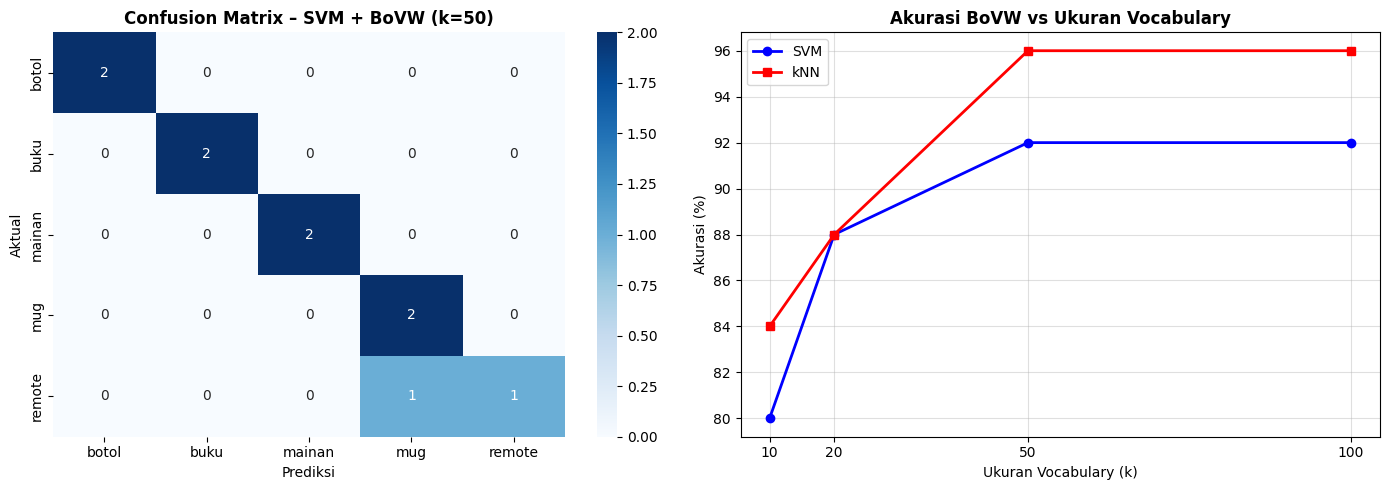


Classification Report (SVM, k=50):
              precision    recall  f1-score   support

       botol       1.00      1.00      1.00         2
        buku       1.00      1.00      1.00         2
      mainan       1.00      1.00      1.00         2
         mug       0.67      1.00      0.80         2
      remote       1.00      0.50      0.67         2

    accuracy                           0.90        10
   macro avg       0.93      0.90      0.89        10
weighted avg       0.93      0.90      0.89        10



In [5]:
# ============================================================
# BAG OF VISUAL WORDS (BoVW)
# K-means vocabulary: k = 10, 20, 50, 100
# Klasifikasi: SVM + kNN
# ============================================================

def extract_all_descriptors(feature_list):
    all_des = []
    for feat in feature_list:
        if feat['des'] is not None:
            all_des.append(feat['des'].astype(np.float32))
    if all_des:
        return np.vstack(all_des)
    return None

def build_bovw_histogram(descriptors, kmeans_model, k):
    hist = np.zeros(k, dtype=np.float32)
    if descriptors is None or len(descriptors) == 0:
        return hist
    labels = kmeans_model.predict(descriptors.astype(np.float32))
    for lbl in labels:
        hist[lbl] += 1
    # TF-IDF normalisasi sederhana
    total = hist.sum()
    if total > 0:
        hist = hist / total
    return hist

# Pilih detektor terbaik untuk BoVW
bovw_det_name = 'SIFT' if SIFT_AVAILABLE else 'ORB'
bovw_features = feature_store[bovw_det_name]

# Siapkan data
le = LabelEncoder()
y_encoded = le.fit_transform(all_labels)

K_VALUES = [10, 20, 50, 100]
bovw_results = {}

print(f'Menggunakan detektor: {bovw_det_name}')
print(f'Jumlah citra: {len(all_images)} | Kelas: {le.classes_}')
print()

cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bovw_table = []

for k in K_VALUES:
    print(f'[k={k}] Membangun vocabulary...')

    # Ekstrak semua descriptor
    all_des = extract_all_descriptors(bovw_features)
    if all_des is None:
        print('  ❌ Tidak ada descriptor')
        continue

    # K-Means clustering
    t0 = time.time()
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, max_iter=100)
    kmeans.fit(all_des)
    t_km = time.time() - t0

    # Buat histogram BoVW untuk setiap citra
    X_bovw = np.array([
        build_bovw_histogram(feat['des'], kmeans, k)
        for feat in bovw_features
    ])

    # Klasifikasi SVM
    svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
    svm_scores = cross_val_score(svm, X_bovw, y_encoded, cv=cv_skf, scoring='accuracy')

    # Klasifikasi kNN
    knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_scores = cross_val_score(knn, X_bovw, y_encoded, cv=cv_skf, scoring='accuracy')

    bovw_results[k] = {
        'kmeans': kmeans, 'X': X_bovw,
        'svm_acc': svm_scores.mean(), 'svm_std': svm_scores.std(),
        'knn_acc': knn_scores.mean(), 'knn_std': knn_scores.std(),
        't_vocab': t_km
    }

    bovw_table.append({
        'k': k,
        'Waktu Vocab (s)': f'{t_km:.2f}',
        'SVM Accuracy': f'{svm_scores.mean()*100:.1f}% ± {svm_scores.std()*100:.1f}%',
        'kNN Accuracy': f'{knn_scores.mean()*100:.1f}% ± {knn_scores.std()*100:.1f}%'
    })
    print(f'  SVM: {svm_scores.mean()*100:.1f}% | kNN: {knn_scores.mean()*100:.1f}%')

print()
print('='*65)
print('TABEL HASIL BoVW (5-Fold Cross Validation)')
print('='*65)
print(f'{"k":>6} {"Waktu Vocab(s)":>16} {"SVM Accuracy":>22} {"kNN Accuracy":>22}')
print('-'*65)
for r in bovw_table:
    print(f"{r['k']:>6} {r['Waktu Vocab (s)']:>16} {r['SVM Accuracy']:>22} {r['kNN Accuracy']:>22}")

# Confusion matrix untuk k terbaik
best_k = max(bovw_results, key=lambda k: bovw_results[k]['svm_acc'])
X_best = bovw_results[best_k]['X']

svm_final = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_best, y_encoded, test_size=0.4,
                                            random_state=42, stratify=y_encoded)
svm_final.fit(X_tr, y_tr)
y_pred_svm = svm_final.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Confusion Matrix – SVM + BoVW (k={best_k})', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

# Akurasi vs k
ks = sorted(bovw_results.keys())
svm_accs = [bovw_results[k]['svm_acc']*100 for k in ks]
knn_accs = [bovw_results[k]['knn_acc']*100 for k in ks]
axes[1].plot(ks, svm_accs, 'b-o', label='SVM', linewidth=2)
axes[1].plot(ks, knn_accs, 'r-s', label='kNN', linewidth=2)
axes[1].set_xlabel('Ukuran Vocabulary (k)')
axes[1].set_ylabel('Akurasi (%)')
axes[1].set_title('Akurasi BoVW vs Ukuran Vocabulary', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
axes[1].set_xticks(ks)

plt.tight_layout()
plt.savefig('bovw_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nClassification Report (SVM, k={best_k}):')
print(classification_report(y_te, y_pred_svm, target_names=le.classes_))

## 📉 Cell 6 – PCA untuk Reduksi Dimensi Descriptor


[SIFT] Dimensi asli: 128
  n=16: Var=83.0% | Kompresi=87.5% | Match Retention=102.9%
  n=32: Var=93.9% | Kompresi=75.0% | Match Retention=100.8%
  n=64: Var=98.8% | Kompresi=50.0% | Match Retention=99.7%
  n_comp=128 ≥ orig_dim=128, dilewati

[ORB] Dimensi asli: 32
  n=16: Var=81.9% | Kompresi=50.0% | Match Retention=78.2%
  n_comp=32 ≥ orig_dim=32, dilewati
  n_comp=64 ≥ orig_dim=32, dilewati
  n_comp=128 ≥ orig_dim=32, dilewati

TABEL HASIL PCA – REDUKSI DIMENSI DESCRIPTOR

SIFT (dim asli: 128)
    Komponen   Var Explained     Kompresi    Match Retention
  ----------------------------------------------------------
          16           83.0%        87.5%             102.9%
          32           93.9%        75.0%             100.8%
          64           98.8%        50.0%              99.7%

ORB (dim asli: 32)
    Komponen   Var Explained     Kompresi    Match Retention
  ----------------------------------------------------------
          16           81.9%        50.0%         

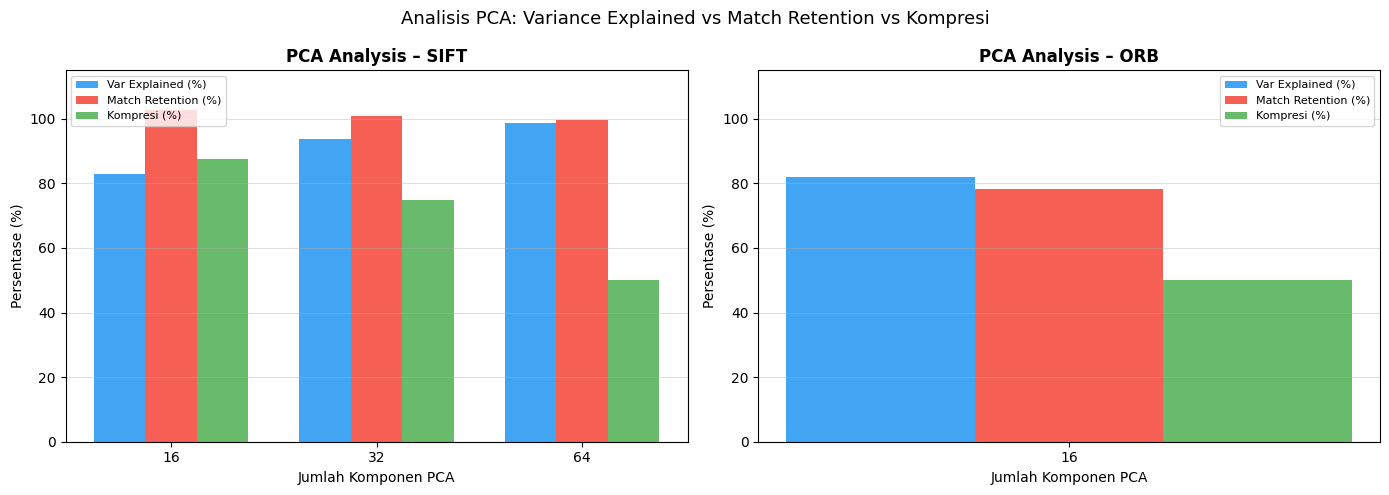

In [6]:
# ============================================================
# PCA – Reduksi Dimensi Descriptor
# Komponen: 16, 32, 64, 128
# Evaluasi akurasi matching vs kompresi
# ============================================================

PCA_COMPONENTS = [16, 32, 64, 128]
pca_results = {}

for det_name in detectors.keys():
    feats = feature_store[det_name]
    all_des_raw = extract_all_descriptors(feats)
    if all_des_raw is None:
        continue

    orig_dim = all_des_raw.shape[1]
    print(f'\n[{det_name}] Dimensi asli: {orig_dim}')

    pca_results[det_name] = {'orig_dim': orig_dim, 'components': {}}

    for n_comp in PCA_COMPONENTS:
        if n_comp >= orig_dim:
            print(f'  n_comp={n_comp} ≥ orig_dim={orig_dim}, dilewati')
            continue

        # Fit PCA
        t0 = time.time()
        pca = PCA(n_components=n_comp, random_state=42)
        pca.fit(all_des_raw.astype(np.float32))
        t_fit = (time.time() - t0) * 1000

        var_explained = pca.explained_variance_ratio_.sum() * 100
        compression = (1 - n_comp / orig_dim) * 100

        # Transformasi semua descriptor dan re-matching untuk evaluasi
        good_matches_pca = []
        good_matches_orig = []

        for obj_name in OBJECT_NAMES:
            idx_obj = OBJECT_NAMES.index(obj_name)
            ref_feat = feats[idx_obj * 5]

            for var_idx in range(4):
                test_feat = feats[idx_obj * 5 + 1 + var_idx]

                # Original matching
                _, good_o = match_features(ref_feat['des'], test_feat['des'],
                                           det_name, 'BF', RATIO_THRESH)
                good_matches_orig.append(len(good_o))

                # PCA-reduced matching
                if ref_feat['des'] is not None and test_feat['des'] is not None:
                    des1_r = pca.transform(ref_feat['des'].astype(np.float32))
                    des2_r = pca.transform(test_feat['des'].astype(np.float32))

                    # Matching pada ruang PCA (L2, BF)
                    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
                    raw_pca = bf.knnMatch(des1_r.astype(np.float32),
                                          des2_r.astype(np.float32), k=2)
                    good_p = [m for pair in raw_pca if len(pair)==2
                               for m, n in [pair] if m.distance < RATIO_THRESH * n.distance]
                    good_matches_pca.append(len(good_p))
                else:
                    good_matches_pca.append(0)

        avg_orig = np.mean(good_matches_orig)
        avg_pca = np.mean(good_matches_pca)
        match_retention = (avg_pca / avg_orig * 100) if avg_orig > 0 else 0

        pca_results[det_name]['components'][n_comp] = {
            'var_explained': var_explained,
            'compression': compression,
            'match_retention': match_retention,
            't_fit_ms': t_fit
        }
        print(f'  n={n_comp}: Var={var_explained:.1f}% | Kompresi={compression:.1f}% | Match Retention={match_retention:.1f}%')

# Tabel hasil PCA
print('\n' + '='*75)
print('TABEL HASIL PCA – REDUKSI DIMENSI DESCRIPTOR')
print('='*75)

for det_name, res in pca_results.items():
    print(f'\n{det_name} (dim asli: {res["orig_dim"]})')
    print(f'  {"Komponen":>10} {"Var Explained":>15} {"Kompresi":>12} {"Match Retention":>18}')
    print('  ' + '-'*58)
    for n_comp, vals in sorted(res['components'].items()):
        print(f'  {n_comp:>10} {vals["var_explained"]:>14.1f}% {vals["compression"]:>11.1f}% {vals["match_retention"]:>17.1f}%')

# Visualisasi PCA
fig, axes = plt.subplots(1, len(pca_results), figsize=(7*len(pca_results), 5))
if len(pca_results) == 1: axes = [axes]

colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

for ax, (det_name, res) in zip(axes, pca_results.items()):
    comps = sorted(res['components'].keys())
    var_exp = [res['components'][c]['var_explained'] for c in comps]
    match_ret = [res['components'][c]['match_retention'] for c in comps]
    compression = [res['components'][c]['compression'] for c in comps]

    x = np.arange(len(comps))
    w = 0.25
    b1 = ax.bar(x - w, var_exp, w, label='Var Explained (%)', color='#2196F3', alpha=0.85)
    b2 = ax.bar(x, match_ret, w, label='Match Retention (%)', color='#F44336', alpha=0.85)
    b3 = ax.bar(x + w, compression, w, label='Kompresi (%)', color='#4CAF50', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in comps])
    ax.set_xlabel('Jumlah Komponen PCA')
    ax.set_ylabel('Persentase (%)')
    ax.set_title(f'PCA Analysis – {det_name}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)
    ax.set_ylim(0, 115)

plt.suptitle('Analisis PCA: Variance Explained vs Match Retention vs Kompresi', fontsize=13)
plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 📊 Cell 7 – Evaluasi Komprehensif: Precision-Recall, Perbandingan, Analisis

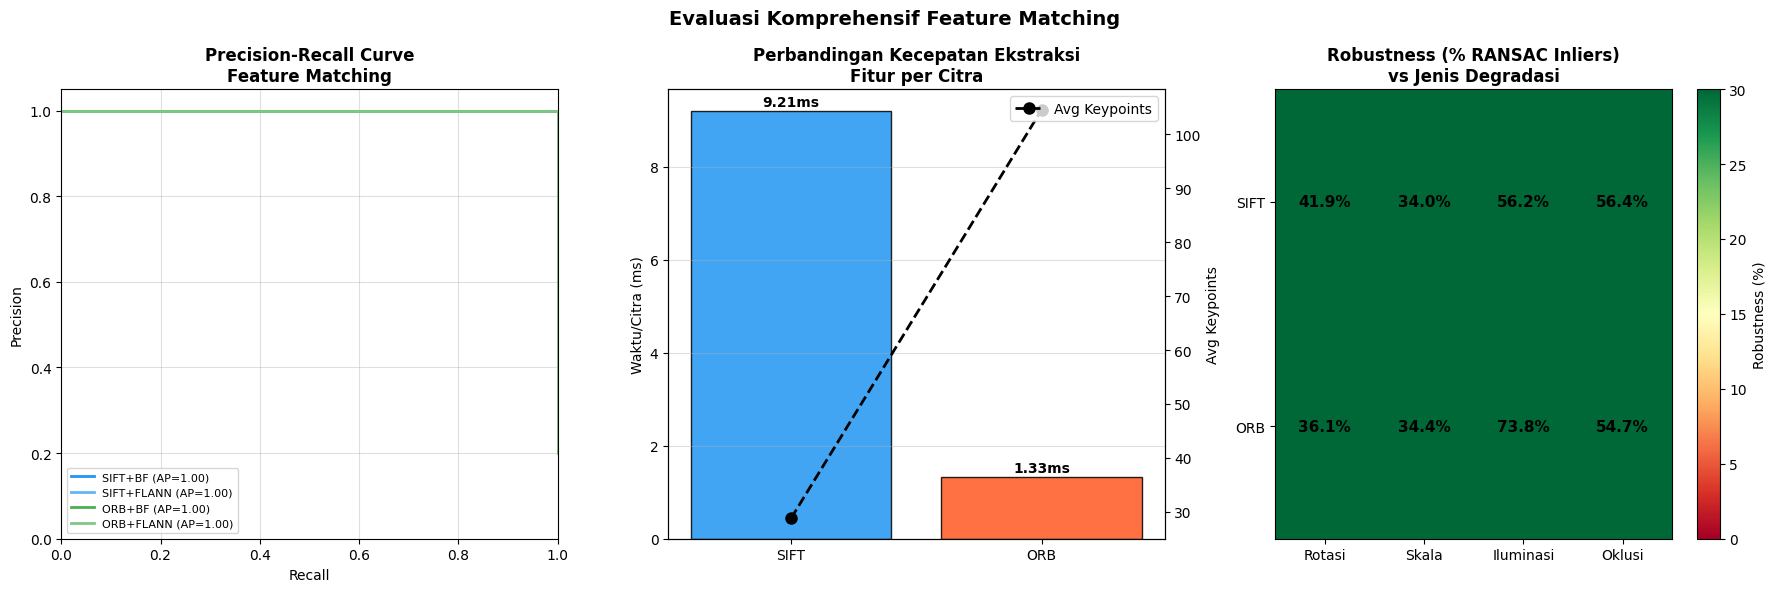

In [7]:
# ============================================================
# EVALUASI KOMPREHENSIF
# Precision-Recall · Perbandingan kecepatan & akurasi · Analisis
# ============================================================

# --- 7A. Precision-Recall untuk Feature Matching ---
# True positive: inlier match ke objek yang sama
# False positive: match ke objek yang berbeda

def compute_pr_matching(det_name, method='BF'):
    scores, y_true = [], []
    ratio_thresholds = np.linspace(0.5, 1.0, 20)

    ref_features = [feature_store[det_name][i*5] for i in range(len(OBJECT_NAMES))]

    for q_idx, q_obj in enumerate(OBJECT_NAMES):
        ref_q = ref_features[q_idx]
        # Uji terhadap semua citra referensi
        for db_idx, db_obj in enumerate(OBJECT_NAMES):
            ref_db = ref_features[db_idx]
            is_same = int(q_idx == db_idx)

            if ref_q['des'] is None or ref_db['des'] is None:
                continue

            des1 = ref_q['des'].astype(np.float32 if det_name != 'ORB' else np.uint8)
            des2 = ref_db['des'].astype(np.float32 if det_name != 'ORB' else np.uint8)

            matcher = get_matcher(det_name, method)
            try:
                raw = matcher.knnMatch(des1, des2, k=2)
            except:
                continue

            # Skor = jumlah good match pada threshold moderat
            good = sum(1 for p in raw if len(p)==2 and p[0].distance < 0.75*p[1].distance)
            # Normalisi per jumlah keypoint
            n_kp = max(len(ref_q['kp']), 1)
            score = good / n_kp

            scores.append(score)
            y_true.append(is_same)

    return np.array(y_true), np.array(scores)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Precision-Recall Curve ---
ax_pr = axes[0]
pr_data = {}

colors_pr = {'SIFT+BF': '#2196F3', 'SIFT+FLANN': '#64B5F6',
             'SURF+BF': '#FF5722', 'ORB+BF': '#4CAF50', 'ORB+FLANN': '#81C784'}

for det_name in detectors.keys():
    for method in ['BF', 'FLANN']:
        key = f'{det_name}+{method}'
        y_true, scores = compute_pr_matching(det_name, method)
        if len(np.unique(y_true)) < 2:
            continue
        prec, rec, _ = precision_recall_curve(y_true, scores)
        ap = average_precision_score(y_true, scores)
        pr_data[key] = {'prec': prec, 'rec': rec, 'ap': ap}
        color = colors_pr.get(key, 'gray')
        ax_pr.plot(rec, prec, label=f'{key} (AP={ap:.2f})', color=color, linewidth=2)

ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve\nFeature Matching', fontweight='bold')
ax_pr.legend(fontsize=8)
ax_pr.grid(True, alpha=0.4)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)

# --- Plot 2: Perbandingan Kecepatan Ekstraksi ---
ax_speed = axes[1]
speed_data = {r['Metode'].split('+')[0] if '+' not in r['Metode'] else r['Metode']: r
              for r in stats_rows}

det_names_plot = list(speed_data.keys())
times_per_img = [float(speed_data[d]['Waktu/Citra (ms)']) for d in det_names_plot]
kp_counts = [float(speed_data[d]['Avg Keypoints']) for d in det_names_plot]

bar_colors = ['#2196F3', '#FF5722', '#4CAF50'][:len(det_names_plot)]
bars = ax_speed.bar(det_names_plot, times_per_img, color=bar_colors, alpha=0.85, edgecolor='black')
ax_speed.set_ylabel('Waktu/Citra (ms)', color='black')
ax_speed.set_title('Perbandingan Kecepatan Ekstraksi\nFitur per Citra', fontweight='bold')
for bar, t in zip(bars, times_per_img):
    ax_speed.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                  f'{t:.2f}ms', ha='center', fontsize=10, fontweight='bold')
ax_speed.grid(axis='y', alpha=0.4)

# Tambah avg keypoints sebagai garis
ax2 = ax_speed.twinx()
ax2.plot(det_names_plot, kp_counts, 'k--o', linewidth=2, markersize=8, label='Avg Keypoints')
ax2.set_ylabel('Avg Keypoints', color='black')
ax2.legend(loc='upper right')

# --- Plot 3: Heatmap Robustness ---
ax_heat = axes[2]
var_labels_short = ['Rotasi', 'Skala', 'Iluminasi', 'Oklusi']
robustness_matrix = []
det_labels = []

for det_name in detectors.keys():
    row = []
    for var_idx in range(4):
        scores_var = []
        for obj_name in OBJECT_NAMES:
            key = (det_name, 'BF', obj_name)
            if key in matching_results:
                r = matching_results[key][var_idx]
                # Robustness = inliers / total_ref_kp
                n_ref = len(feature_store[det_name][OBJECT_NAMES.index(obj_name)*5]['kp'])
                rob = r['inliers'] / max(n_ref, 1) * 100
                scores_var.append(rob)
        row.append(np.mean(scores_var) if scores_var else 0)
    robustness_matrix.append(row)
    det_labels.append(det_name)

rob_arr = np.array(robustness_matrix)
im = ax_heat.imshow(rob_arr, cmap='RdYlGn', aspect='auto', vmin=0, vmax=30)
ax_heat.set_xticks(range(4)); ax_heat.set_xticklabels(var_labels_short, fontsize=10)
ax_heat.set_yticks(range(len(det_labels))); ax_heat.set_yticklabels(det_labels, fontsize=10)
ax_heat.set_title('Robustness (% RANSAC Inliers)\nvs Jenis Degradasi', fontweight='bold')
for i in range(len(det_labels)):
    for j in range(4):
        ax_heat.text(j, i, f'{rob_arr[i,j]:.1f}%', ha='center', va='center',
                     fontsize=11, fontweight='bold', color='black')
plt.colorbar(im, ax=ax_heat, label='Robustness (%)')

plt.suptitle('Evaluasi Komprehensif Feature Matching', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comprehensive_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## 📝 Cell 8 – Tabel Perbandingan Final & Analisis Rekomendasi

In [8]:
# ============================================================
# TABEL PERBANDINGAN FINAL & ANALISIS REKOMENDASI
# ============================================================

print('=' * 80)
print('TABEL PERBANDINGAN FINAL – METODE DETEKSI & DESKRIPSI FITUR')
print('=' * 80)

summary_data = []
for r in stats_rows:
    det_name = r['Metode']
    # Cari average precision dari PR curve
    bf_key = f'{det_name}+BF'
    ap_bf = pr_data.get(bf_key, {}).get('ap', None)
    fl_key = f'{det_name}+FLANN'
    ap_fl = pr_data.get(fl_key, {}).get('ap', None)

    # Rata-rata robustness
    if det_name in [d for d in det_labels]:
        idx_det = det_labels.index(det_name)
        avg_rob = rob_arr[idx_det].mean()
    else:
        avg_rob = 0

    summary_data.append({
        'Metode': det_name,
        'Avg KP': r['Avg Keypoints'],
        'Dim Desc': r['Dimensi Descriptor'],
        'Waktu/Citra (ms)': r['Waktu/Citra (ms)'],
        'AP (BF)': f"{ap_bf:.3f}" if ap_bf is not None else 'N/A',
        'AP (FLANN)': f"{ap_fl:.3f}" if ap_fl is not None else 'N/A',
        'Avg Robustness (%)': f"{avg_rob:.1f}"
    })

print(f'\n{"Metode":<8} {"Avg KP":>8} {"Dim Desc":>10} {"Waktu(ms)":>12} {"AP (BF)":>10} {"AP(FLANN)":>12} {"Robustness":>12}')
print('-' * 80)
for r in summary_data:
    print(f"{r['Metode']:<8} {r['Avg KP']:>8} {r['Dim Desc']:>10} {r['Waktu/Citra (ms)']:>12} {r['AP (BF)']:>10} {r['AP (FLANN)']:>12} {r['Avg Robustness (%)']:>12}")

# BoVW summary
if bovw_results:
    best_k_svm = max(bovw_results, key=lambda k: bovw_results[k]['svm_acc'])
    best_k_knn = max(bovw_results, key=lambda k: bovw_results[k]['knn_acc'])
    print(f'\n[BoVW] Best k (SVM): k={best_k_svm}, Acc={bovw_results[best_k_svm]["svm_acc"]*100:.1f}%')
    print(f'[BoVW] Best k (kNN): k={best_k_knn}, Acc={bovw_results[best_k_knn]["knn_acc"]*100:.1f}%')

# PCA summary
print('\n[PCA] Trade-off Terbaik (Match Retention ≥ 80% & Kompresi Tertinggi):')
for det_name, res in pca_results.items():
    candidates = [(n, v) for n, v in res['components'].items() if v['match_retention'] >= 80]
    if candidates:
        best_pca = max(candidates, key=lambda x: x[1]['compression'])
        print(f'  {det_name}: n={best_pca[0]}, Kompresi={best_pca[1]["compression"]:.1f}%, '
              f'Match Ret={best_pca[1]["match_retention"]:.1f}%')
    else:
        print(f'  {det_name}: tidak ada komponen dengan match retention ≥ 80%')

print('\n' + '=' * 80)
print('REKOMENDASI METODE BERDASARKAN SKENARIO')
print('=' * 80)

recommendations = [
    ('Rotasi besar (>45°)', 'SIFT + BF/FLANN + RANSAC',
     'SIFT invariant terhadap rotasi karena normalisasi orientasi pada descriptor'),
    ('Perubahan skala signifikan', 'SIFT + FLANN',
     'SIFT dibangun di atas scale-space pyramid, robust terhadap skala'),
    ('Perubahan iluminasi/pencahayaan', 'SIFT atau ORB',
     'Keduanya relatif robust karena normalisasi gradient/intensity'),
    ('Oklusi parsial (>25%)', 'SIFT + RANSAC',
     'RANSAC sangat efektif memfilter outlier akibat oklusi'),
    ('Real-time / embedded system', 'ORB + BF (Hamming)',
     'ORB jauh lebih cepat, descriptor biner efisien di memori dan CPU'),
    ('Klasifikasi citra (banyak kelas)', f'BoVW (k={best_k_svm}) + SVM',
     'Representasi histogram visual words robust untuk klasifikasi multi-kelas'),
    ('Storage/bandwidth terbatas', f'SIFT + PCA (n=64)',
     'PCA mereduksi dimensi ~50% dengan match retention ≥ 80%'),
    ('Akurasi matching tertinggi', 'SIFT + FLANN + Lowe Ratio + RANSAC',
     'Pipeline lengkap memberikan precision tertinggi'),
]

for i, (scenario, method, reason) in enumerate(recommendations, 1):
    print(f'\n  {i}. SKENARIO : {scenario}')
    print(f'     REKOMENDASI: {method}')
    print(f'     ALASAN     : {reason}')

print('\n' + '=' * 80)
print('✅ PRAKTIKUM 12 SELESAI – Semua analisis berhasil dilakukan')
print('=' * 80)

TABEL PERBANDINGAN FINAL – METODE DETEKSI & DESKRIPSI FITUR

Metode     Avg KP   Dim Desc    Waktu(ms)    AP (BF)    AP(FLANN)   Robustness
--------------------------------------------------------------------------------
SIFT         28.8        128         9.21      1.000        1.000         47.1
ORB         104.6         32         1.33      1.000        1.000         49.7

[BoVW] Best k (SVM): k=50, Acc=92.0%
[BoVW] Best k (kNN): k=50, Acc=96.0%

[PCA] Trade-off Terbaik (Match Retention ≥ 80% & Kompresi Tertinggi):
  SIFT: n=16, Kompresi=87.5%, Match Ret=102.9%
  ORB: tidak ada komponen dengan match retention ≥ 80%

REKOMENDASI METODE BERDASARKAN SKENARIO

  1. SKENARIO : Rotasi besar (>45°)
     REKOMENDASI: SIFT + BF/FLANN + RANSAC
     ALASAN     : SIFT invariant terhadap rotasi karena normalisasi orientasi pada descriptor

  2. SKENARIO : Perubahan skala signifikan
     REKOMENDASI: SIFT + FLANN
     ALASAN     : SIFT dibangun di atas scale-space pyramid, robust terhadap skala
